# Separate validation — unseen datasets
Evaluate frozen DRS-only LOSO checkpoints on two separate validation datasets: four newly simulated wavelength-dependent μs′ sets produced by changing K, and the three original Group 2 optical-property μs′ sets. Each condition is compared with the same held-out subject's RMSE on the original validation dataset.

## Parameters
Set `TARGET` to `'hc'` or `'sto2'`. The notebook preserves the LOSO pairing and applies each checkpoint's training-fold normalization to both new datasets.

In [5]:
from pathlib import Path
import os, subprocess, sys

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():  # VS Code may start in notebooks/
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)

SRC_DIR = ROOT / 'src'
sys.path.insert(0, str(SRC_DIR))
SUBPROCESS_ENV = os.environ.copy()
SUBPROCESS_ENV['PYTHONPATH'] = str(SRC_DIR) + os.pathsep + SUBPROCESS_ENV.get('PYTHONPATH', '')

TARGET = 'hc'  # 'hc' or 'sto2'
FOLDS = None     # None for all folds, or e.g. '1,3,10-20'
DEVICE = 'cuda'  # 'auto', 'cpu', 'cuda', or e.g. 'cuda:1'
BATCH_SIZE = 4096
ROWS_PER_CONDITION = 12960
SAVE_PREDICTIONS = False

if TARGET not in {'hc', 'sto2'}:
    raise ValueError("TARGET must be 'hc' or 'sto2'")
CHECKPOINT_DIR = Path(f'artifacts/stage2/baseline/{TARGET}')
ORIGINAL_RESULTS = CHECKPOINT_DIR / 'loso_results.csv'
ARTIFACT_ROOT = Path('artifacts/stage2/unseen_dataset_validation')
FIGURE_DIR = Path('results/figures/stage2/unseen_dataset_validation')
UNIT = 'µM' if TARGET == 'hc' else 'fraction'
TARGET_DISPLAY = 'tHb' if TARGET == 'hc' else 'StO₂'
DATASETS = {
    'unseen_scattering': {
        'label': 'Modified-K μs′ sets',
        'mat': Path('data/NIRS_Absolute_Val_Dataset_new.mat'),
        'conditions': 4,
    },
    'unseen_wm': {
        'label': 'Original Group 2 μs′ sets',
        'mat': Path('data/NIRS_Absolute_Val_Dataset_diffwm.mat'),
        'conditions': 3,
    },
}

TARGET, CHECKPOINT_DIR, ORIGINAL_RESULTS, DATASETS

('hc',
 PosixPath('artifacts/stage2/baseline/hc'),
 PosixPath('artifacts/stage2/baseline/hc/loso_results.csv'),
 {'unseen_scattering': {'label': 'Modified-K μs′ sets',
   'mat': PosixPath('data/NIRS_Absolute_Val_Dataset_new.mat'),
   'conditions': 4},
  'unseen_wm': {'label': 'Original Group 2 μs′ sets',
   'mat': PosixPath('data/NIRS_Absolute_Val_Dataset_diffwm.mat'),
   'conditions': 3}})

## 1. Evaluate both unseen datasets
Each fold evaluates only its LOSO test subject. Dataset-specific fold JSON files make inference resumable.

In [6]:
for dataset_key, specification in DATASETS.items():
    validation_mat = specification['mat']
    output_dir = ARTIFACT_ROOT / dataset_key / TARGET
    if not validation_mat.is_file():
        raise FileNotFoundError(f'Missing validation dataset: {validation_mat}')
    command = [
        sys.executable, '-m', 'subject_nirs.stage2.unseen_scattering',
        '--target', TARGET,
        '--checkpoint_dir', str(CHECKPOINT_DIR),
        '--validation_mat', str(validation_mat),
        '--output_dir', str(output_dir),
        '--device', DEVICE,
        '--batch_size', str(BATCH_SIZE),
        '--rows_per_sim', str(ROWS_PER_CONDITION),
    ]
    if FOLDS:
        command.extend(['--folds', FOLDS])
    if not SAVE_PREDICTIONS:
        command.append('--no_save_predictions')
    print(f"\n=== {specification['label']} ===")
    subprocess.run(command, cwd=ROOT, env=SUBPROCESS_ENV, check=True)


=== Modified-K μs′ sets ===
target=hc device=cuda folds=154 source=mat rows=7,983,360 output=artifacts/stage2/unseen_dataset_validation/unseen_scattering/hc
[001/154] fold 001: cached
[002/154] fold 002: cached
[003/154] fold 003: cached
[004/154] fold 004: cached
[005/154] fold 005: cached
[006/154] fold 006: cached
[007/154] fold 007: cached
[008/154] fold 008: cached
[009/154] fold 009: cached
[010/154] fold 010: cached
[011/154] fold 011: cached
[012/154] fold 012: cached
[013/154] fold 013: cached
[014/154] fold 014: cached
[015/154] fold 015: cached
[016/154] fold 016: cached
[017/154] fold 017: cached
[018/154] fold 018: cached
[019/154] fold 019: cached
[020/154] fold 020: cached
[021/154] fold 021: cached
[022/154] fold 022: cached
[023/154] fold 023: cached
[024/154] fold 024: cached
[025/154] fold 025: cached
[026/154] fold 026: cached
[027/154] fold 027: cached
[028/154] fold 028: cached
[029/154] fold 029: cached
[030/154] fold 030: cached
[031/154] fold 031: cached
[032/

## 2. Plot paired subject-level ΔRMSE
For subject/fold $i$ and unseen condition $k$, $\Delta RMSE_{ik}=RMSE_{ik}^{new}-RMSE_i^{original}$. Positive values indicate worse performance. The panel annotations report the median change, percentage of subjects that worsened, and Holm-adjusted paired Wilcoxon p-value.

In [7]:
if not ORIGINAL_RESULTS.is_file():
    raise FileNotFoundError(f'Missing original LOSO results: {ORIGINAL_RESULTS}')
plot_command = [
    sys.executable, '-m', 'subject_nirs.stage2.unseen_scattering_plot',
    '--original_csv', str(ORIGINAL_RESULTS),
    '--target', TARGET,
    '--output_dir', str(FIGURE_DIR),
    '--output_prefix', f'fig_unseen_dataset_validation_{TARGET}_delta_rmse',
    '--unit', UNIT,
    '--title', f'DRS-only {TARGET_DISPLAY} robustness across μs′ validation sets',
]
for dataset_key, specification in DATASETS.items():
    metrics_csv = ARTIFACT_ROOT / dataset_key / TARGET / 'per_sim_metrics.csv'
    if not metrics_csv.is_file():
        raise FileNotFoundError(f'Evaluation did not create {metrics_csv}')
    plot_command.extend([
        '--new_dataset', dataset_key, specification['label'],
        str(specification['conditions']), str(metrics_csv),
    ])
subprocess.run(plot_command, cwd=ROOT, env=SUBPROCESS_ENV, check=True)

saved: results/figures/stage2/unseen_dataset_validation/fig_unseen_dataset_validation_hc_delta_rmse.png
saved: results/figures/stage2/unseen_dataset_validation/fig_unseen_dataset_validation_hc_delta_rmse_paired_detail.csv
saved: results/figures/stage2/unseen_dataset_validation/fig_unseen_dataset_validation_hc_delta_rmse_summary.csv
saved: results/figures/stage2/unseen_dataset_validation/fig_unseen_dataset_validation_hc_delta_rmse_metadata.json


CompletedProcess(args=['/home/md703/.conda/envs/yc_ae/bin/python', '-m', 'subject_nirs.stage2.unseen_scattering_plot', '--original_csv', 'artifacts/stage2/baseline/hc/loso_results.csv', '--target', 'hc', '--output_dir', 'results/figures/stage2/unseen_dataset_validation', '--output_prefix', 'fig_unseen_dataset_validation_hc_delta_rmse', '--unit', 'µM', '--title', 'DRS-only tHb robustness across μs′ validation sets', '--new_dataset', 'unseen_scattering', 'Modified-K μs′ sets', '4', 'artifacts/stage2/unseen_dataset_validation/unseen_scattering/hc/per_sim_metrics.csv', '--new_dataset', 'unseen_wm', 'Original Group 2 μs′ sets', '3', 'artifacts/stage2/unseen_dataset_validation/unseen_wm/hc/per_sim_metrics.csv'], returncode=0)

## 3. Display the saved figure and statistics

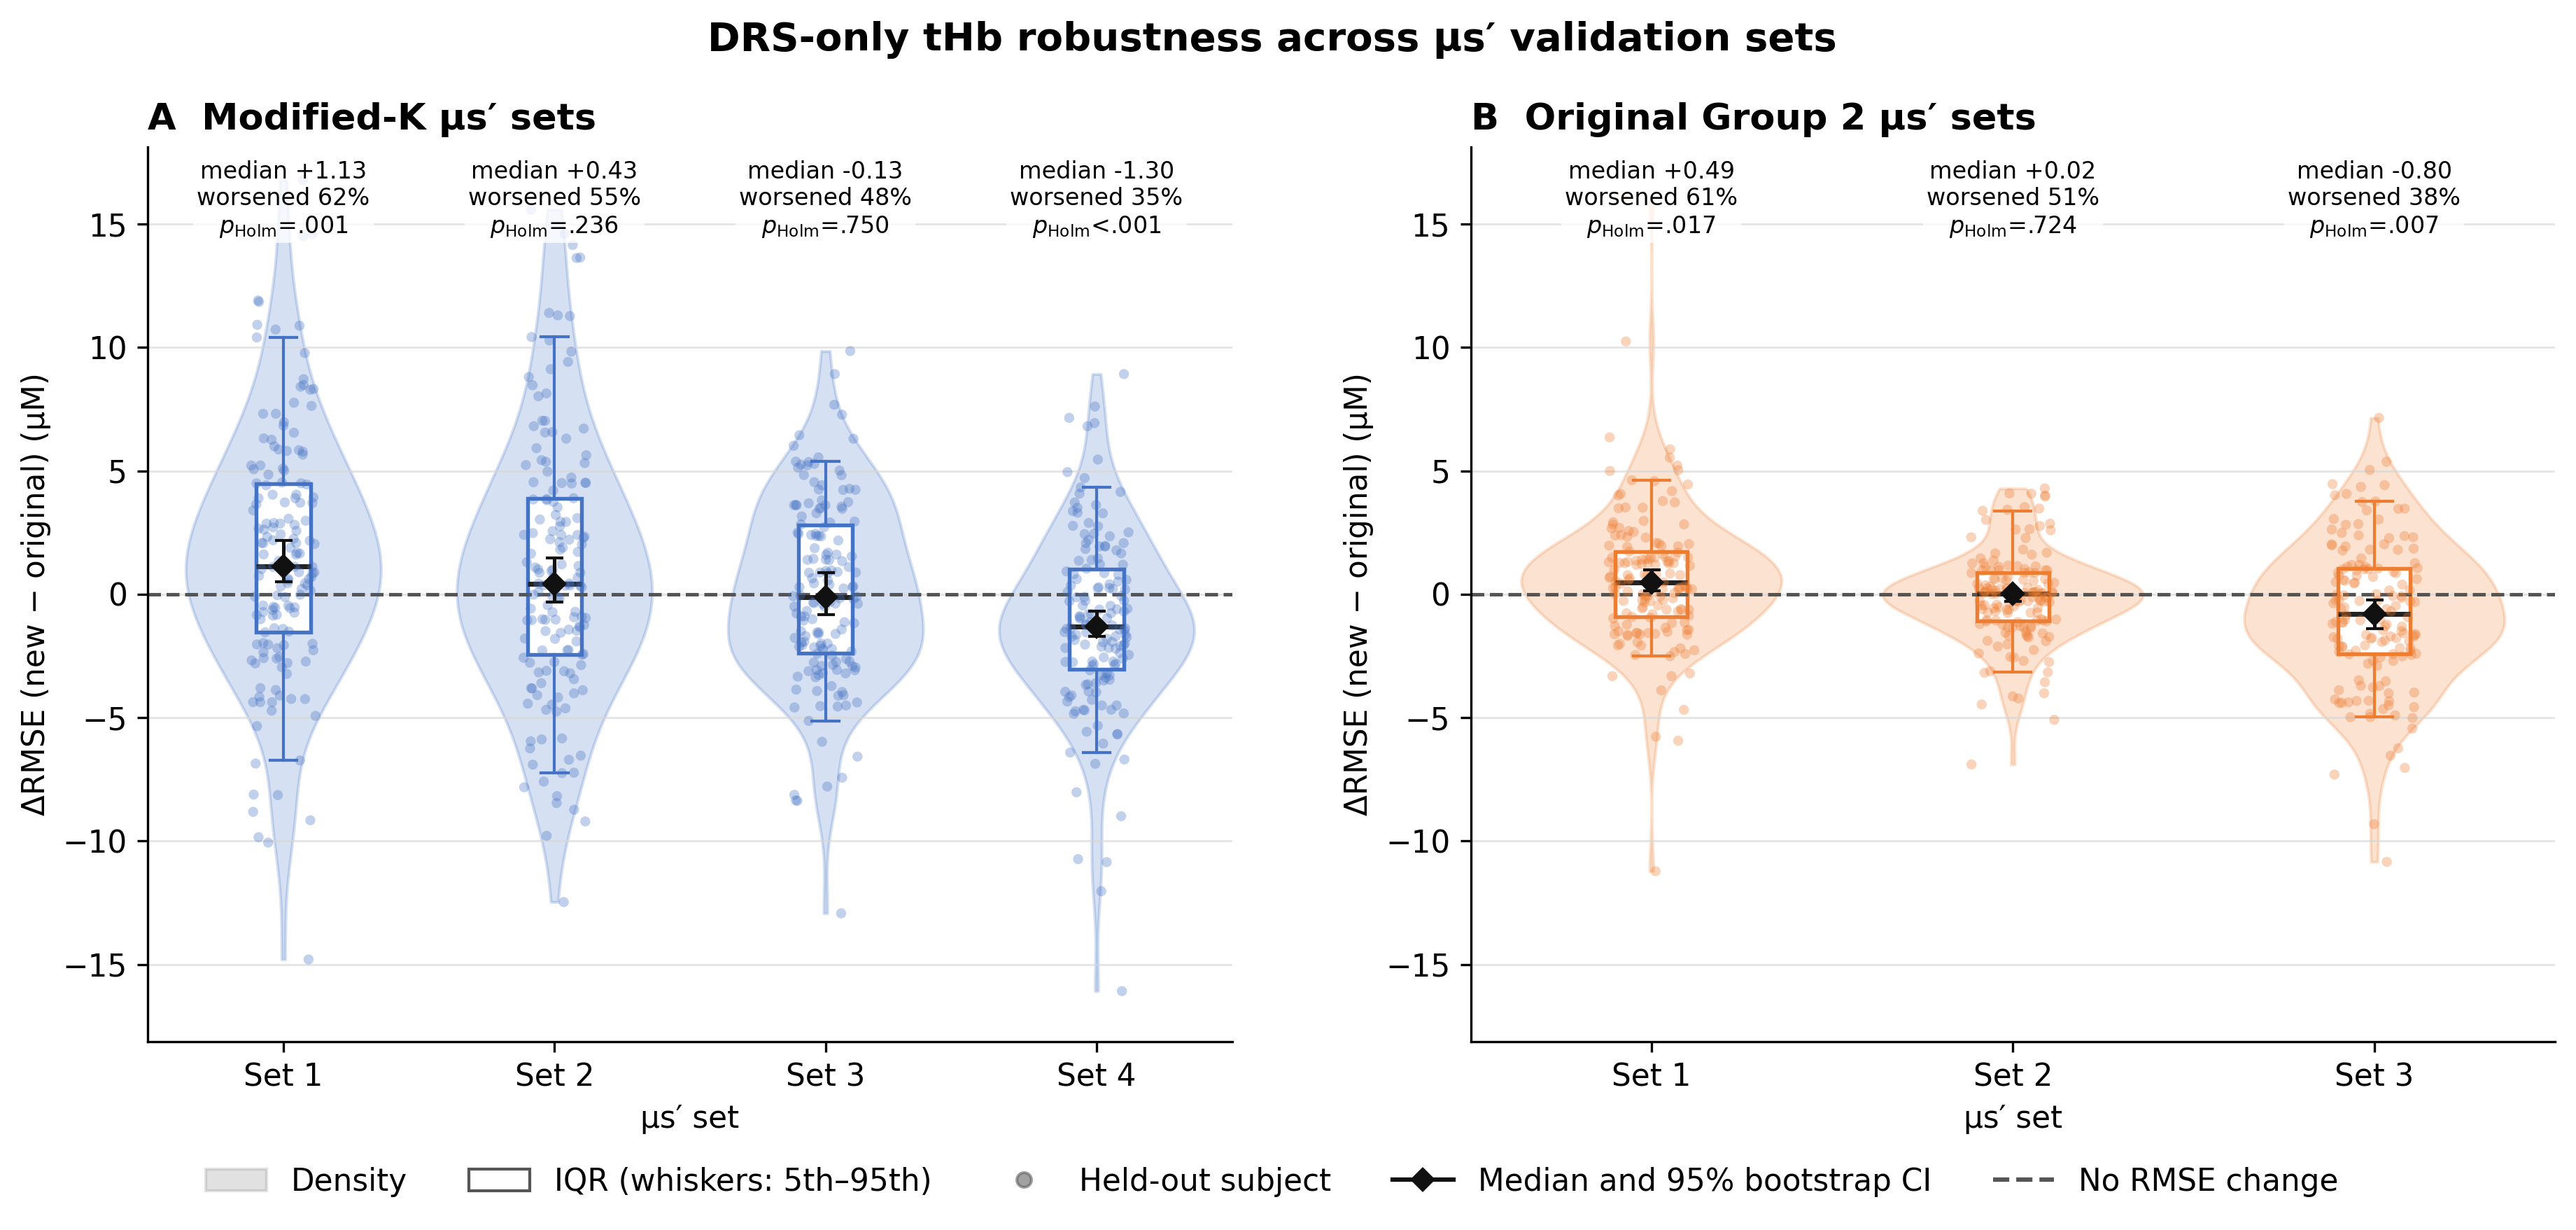

,dataset_key,dataset_label,condition,n_subjects,median_delta_RMSE,q25_delta_RMSE,q75_delta_RMSE,median_ci_low,median_ci_high,worsened_fraction,improved_fraction,unchanged_fraction,wilcoxon_p,rank_biserial,holm_p
0,unseen_scattering,Modified-K μs′ sets,1,154,1.134639,-1.533041,4.482998,0.507511,2.180288,0.616883,0.383117,0.0,0.000238,0.341433,0.001425
1,unseen_scattering,Modified-K μs′ sets,2,154,0.432844,-2.441609,3.882844,-0.308751,1.473184,0.551948,0.448052,0.0,0.078773,0.163301,0.236319
2,unseen_scattering,Modified-K μs′ sets,3,154,-0.128623,-2.383770,2.804295,-0.835159,0.868762,0.480519,0.519481,0.0,0.750197,0.029577,0.750197
3,unseen_scattering,Modified-K μs′ sets,4,154,-1.302806,-3.037107,1.009018,-1.709461,-0.686461,0.350649,0.649351,0.0,0.000122,-0.356850,0.000857
4,unseen_wm,Original Group 2 μs′ sets,1,154,0.486192,-0.905050,1.721300,0.126106,0.987900,0.610390,0.389610,0.0,0.004212,0.265857,0.016849
5,unseen_wm,Original Group 2 μs′ sets,2,154,0.020311,-1.088443,0.865398,-0.277109,0.093035,0.506494,0.493506,0.0,0.361850,-0.084709,0.723700
6,unseen_wm,Original Group 2 μs′ sets,3,154,-0.804858,-2.420030,1.037490,-1.386722,-0.236090,0.383117,0.616883,0.0,0.001370,-0.297361,0.006849


In [8]:
import pandas as pd
from IPython.display import Image, display

PREFIX = f'fig_unseen_dataset_validation_{TARGET}_delta_rmse'
PNG_PATH = FIGURE_DIR / f'{PREFIX}.png'
SUMMARY_CSV = FIGURE_DIR / f'{PREFIX}_summary.csv'
display(Image(filename=str(PNG_PATH), width=1200))
display(pd.read_csv(SUMMARY_CSV))